# Stock Price Regression — Project 2.7
## Analysis and Regression on the 'stock' Dataset
Cocco Mattia 65336
Lepuri Tomas 65358

This project aims to perform an in-depth analysis of the 'stock' dataset.
After reviewing the information provided by OpenML, we observed that the dataset contains the daily stock prices of 10 aerospace companies, from 1988 to 1991.

### 1. Dataset Analysis

After importing `fetch_openml` from `sklearn.datasets`, we downloaded the object containing the dataset and built a dataframe from the data in `azioni.data`, adding the tenth company column from `azioni.target`, which is the target variable.
Finally, we printed the first 10 rows of the resulting dataframe.

The fetch generates a warning because two versions of the stock dataset exist, but version 1 — the correct one matching the project specs (id=223) — is returned.

In [162]:
import pandas as pd
from sklearn.datasets import fetch_openml

azioni=fetch_openml(name = 'stock')
df= pd.DataFrame(azioni.data)
df['company10']=azioni.target
df[:10]

/opt/anaconda3/lib/python3.12/site-packages/sklearn/datasets/_openml.py:320: UserWarning: Multiple active versions of the dataset matching the name stock exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=223
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=841

  warn(warning_msg)


,company1,company2,company3,company4,company5,company6,company7,company8,company9,company10
0,17.219,50.500,18.750,43.000,60.875,26.375,67.750,19.000,48.750,34.875
1,17.891,51.375,19.625,44.000,62.000,26.125,68.125,19.125,48.750,35.625
2,18.438,50.875,19.875,43.875,61.875,27.250,68.500,18.250,49.000,36.375
3,18.672,51.500,20.000,44.000,62.625,27.875,69.375,18.375,49.625,36.250
4,17.438,49.000,20.000,41.375,59.750,25.875,63.250,16.500,47.500,35.500
5,18.109,49.000,19.500,41.875,59.625,26.625,66.250,17.125,47.750,34.375
6,18.563,49.375,19.125,42.500,60.750,27.250,65.750,16.875,47.875,34.000
7,18.672,50.125,19.250,43.000,61.750,28.000,66.000,16.875,47.250,34.625
8,18.563,49.750,19.000,43.250,61.750,29.000,65.750,17.125,47.000,34.875
9,19.063,50.500,19.125,43.875,61.875,29.625,66.875,17.750,47.375,36.000


### 2. Preprocessing

Before the analysis, from the OpenML documentation, we had already noted the absence of nominal variables and missing values. We nonetheless printed the brief description from the `DESCR` attribute, the data types (float), and checked for missing values using `info()`, which confirmed the presence of only numerical features and no missing values.

We also printed descriptive statistics using `describe()`, useful later for contextualising the numerical error metrics.

In [164]:
azioni.DESCR

'**Author**:   \n**Source**: Unknown -   \n**Please cite**:   \n\nThis is a dataset obtained from the StatLib repository. Here is the included description:\n\n The data provided are daily stock prices from January 1988 through October 1991, for ten aerospace companies.\n\n Source: collection of regression datasets by Luis Torgo (ltorgo@ncc.up.pt) at\n http://www.ncc.up.pt/~ltorgo/Regression/DataSets.html\n Original source: StatLib repository. \n Characteristics: 950 cases, 10 continuous attributes\n\nDownloaded from openml.org.'

In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   company1   950 non-null    float64
 1   company2   950 non-null    float64
 2   company3   950 non-null    float64
 3   company4   950 non-null    float64
 4   company5   950 non-null    float64
 5   company6   950 non-null    float64
 6   company7   950 non-null    float64
 7   company8   950 non-null    float64
 8   company9   950 non-null    float64
 9   company10  950 non-null    float64
dtypes: float64(10)
memory usage: 74.3 KB


In [166]:
df.describe()

,company1,company2,company3,company4,company5,company6,company7,company8,company9,company10
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,37.925592,43.955526,18.704474,45.352895,60.863553,24.122632,70.673421,23.294211,44.214211,46.994079
std,10.759764,11.377308,2.730364,5.606898,14.299412,5.530962,6.773101,2.970152,4.270098,6.539420
min,17.219000,19.250000,12.750000,34.375000,27.750000,14.125000,58.000000,16.375000,31.500000,34.000000
25%,27.781000,35.406250,16.125000,41.375000,49.656250,18.000000,65.625000,21.250000,41.750000,41.375000
50%,38.922000,49.062500,19.375000,43.937500,61.750000,25.750000,68.625000,22.500000,44.750000,46.687500
75%,46.875000,53.250000,20.875000,48.125000,71.843750,28.875000,76.375000,26.375000,47.625000,52.125000
max,61.500000,60.250000,25.125000,60.125000,94.125000,35.250000,87.250000,29.250000,53.000000,62.000000


We plotted boxplots for each variable to identify potential outliers, and found that only `company4` and `company9` contain them. Given their low count, we decided to keep the outliers and test the models without removing them.

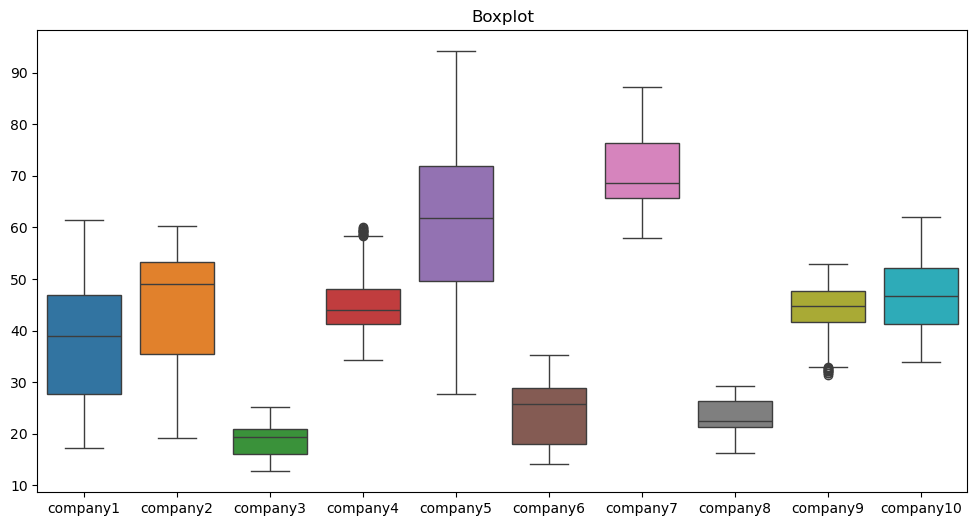

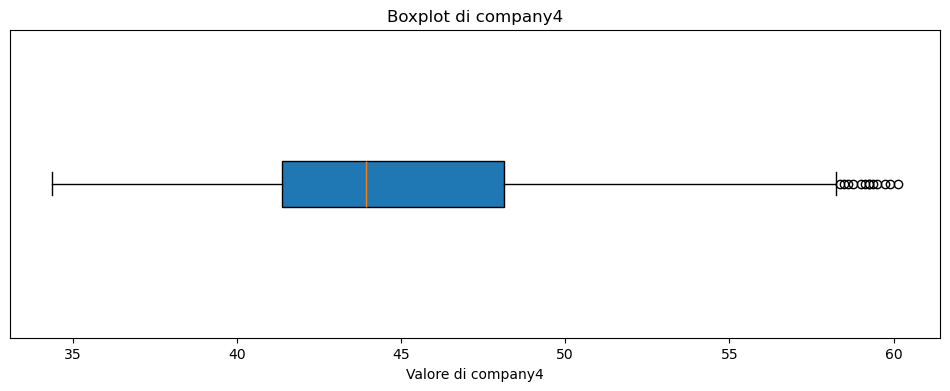

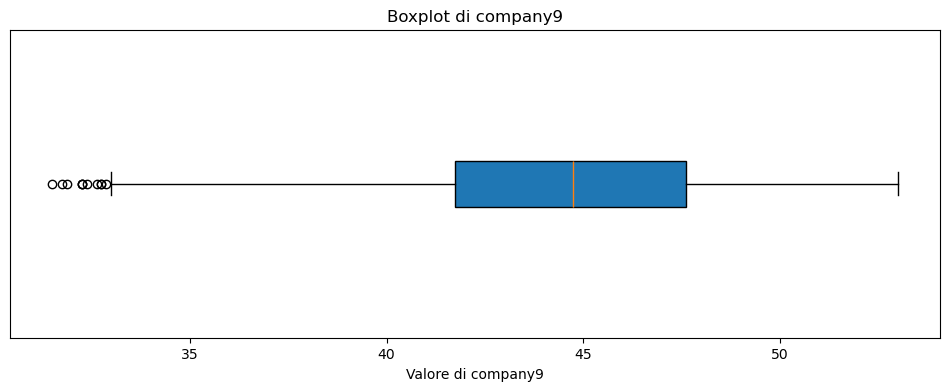

In [168]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[df.columns])
plt.title("Boxplot")
plt.show()

plt.figure(figsize=(12, 4))
plt.boxplot(df['company4'], vert=False, patch_artist=True)
plt.title("Boxplot di company4")
plt.xlabel("Valore di company4")
plt.yticks([],[])
plt.show()

plt.figure(figsize=(12, 4))
plt.boxplot(df['company9'], vert=False, patch_artist=True)
plt.title("Boxplot di company9")
plt.xlabel("Valore di company9")
plt.yticks([],[])
plt.show()




We then separated the target variable from the features and split into training and test sets using an 80-20 ratio.

We scaled features and target separately, fitting the scaler only on the training set and applying it to the test set, to prevent data leakage.

We chose standardisation over normalisation because PCA — applied later — requires standardised data.

Temporary `_init` variables were used to store the unstandardised split data.

In [170]:
from sklearn.model_selection import train_test_split

X= df.drop(columns=['company10'])
y= df['company10']

X_train_init, X_test_init, y_train_init, y_test_init = train_test_split(X, y, test_size=0.2, random_state=42)


In [171]:
from sklearn.preprocessing import StandardScaler

scaler_X= StandardScaler()
scaler_y= StandardScaler()

X_train= scaler_X.fit_transform(X_train_init)
X_test= scaler_X.transform(X_test_init)
y_train= scaler_y.fit_transform(y_train_init.values.reshape(-1,1)).ravel()
y_test= y_test_init

### 3. Regression

Regression involves predicting the target variable (`company10`) from the remaining nine company values.
The dataframe had already been split into features and target (`X` and `y`) and into training and test sets (80% and 20% respectively).

Each model was evaluated on both the test set and the training set, to check for overfitting and/or underfitting.

In some cases the printed value is 0.0 due to rounding, but the actual values are very small rather than exactly zero.

We also defined a dictionary to store each model's evaluation metrics for later comparison.

In [173]:
metriche={}

We implemented the `symmetric_mean_absolute_percentage_error` function, which takes two arrays and returns the SMAPE value.

In [175]:
def symmetric_mean_absolute_percentage_error(reali, predetti):
    reali=reali.tolist()
    predetti=predetti.tolist()
    smape=0
    i=len(reali)
    for n in range(i):
        num=abs(reali[n]-predetti[n])/(abs(reali[n])+abs(predetti[n]))
        smape+=num

    return smape/i

#### 3.1 Linear Regression

The first model is a mathematical model: Linear Regression.

We imported and initialised the model with default parameters and fitted it for regression.

In [178]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train);

We evaluated the model using MAE, MAPE, RMSE, and SMAPE, then saved the values in the corresponding dictionary entry.

As mentioned, printed values are rounded — the intercept displays as 0.0 due to rounding, but its actual value is approximately $3 \cdot 10^{-17}$.

The numerical error metrics (MAE, RMSE) are not particularly low relative to the target variable's scale, suggesting a non-excellent result.

The percentage metrics (MAPE, SMAPE) are reasonably low, indicating acceptable performance overall.

Since the metrics are similar on both training and test sets, we rule out overfitting. As the model produces errors on both sets, we conclude there is slight underfitting.

In [180]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error

y_pred_temp = lr_model.predict(X_test)
y_pred= scaler_y.inverse_transform(y_pred_temp.reshape(-1,1)).ravel()

mae = round(mean_absolute_error(y_test, y_pred), 3)
mape = round(mean_absolute_percentage_error(y_test, y_pred), 3)
rmse = round(root_mean_squared_error(y_test, y_pred), 3)
smape= round(symmetric_mean_absolute_percentage_error(y_test, y_pred), 3)

metriche['regressioneLineare']= {
    'mae': mae,
    'mape': mape,
    'rmse': rmse,
    'smape': smape
}

print("Linear Regressor Coefficients")
print("Slope Coefficient:", round(lr_model.coef_[0], 3))
print("Intercept:", round(lr_model.intercept_, 3), "\n \n")

print("Error Metrics sul test set")
print("Mean Absolute Error:", mae)
print("Mean Absolute percentage error:", mape)
print("Root Mean Squared Error:", rmse)
print("Symmetric Mean Absolute Percentage Error:", smape)


#test sul training set per verificare la presenza di overfitting
y_pred_temp_prova = lr_model.predict(X_train)
y_pred_prova= scaler_y.inverse_transform(y_pred_temp_prova.reshape(-1,1)).ravel()

mae = round(mean_absolute_error(y_train_init, y_pred_prova), 3)
mape = round(mean_absolute_percentage_error(y_train_init, y_pred_prova), 3)
rmse = round(root_mean_squared_error(y_train_init, y_pred_prova), 3)
smape= round(symmetric_mean_absolute_percentage_error(y_train_init, y_pred_prova), 3)

print("\nError Metrics sul training set")
print("Mean Absolute Error:", mae)
print("Mean Absolute percentage error:", mape)
print("Root Mean Squared Error:", rmse)
print("Symmetric Mean Absolute Percentage Error:", smape)

Linear Regressor Coefficients
Slope Coefficient: 0.744
Intercept: 0.0 
 

Error Metrics sul test set
Mean Absolute Error: 1.797
Mean Absolute percentage error: 0.039
Root Mean Squared Error: 2.359
Symmetric Mean Absolute Percentage Error: 0.019

Error Metrics sul training set
Mean Absolute Error: 1.827
Mean Absolute percentage error: 0.04
Root Mean Squared Error: 2.314
Symmetric Mean Absolute Percentage Error: 0.02


As this is only the first model, we do not yet have enough benchmarks to determine whether it is the best for this problem. We therefore print a plot showing the distances between real and predicted values for the first 50 samples — not the most informative chart, but it gave us a clear and easy-to-interpret visual baseline.

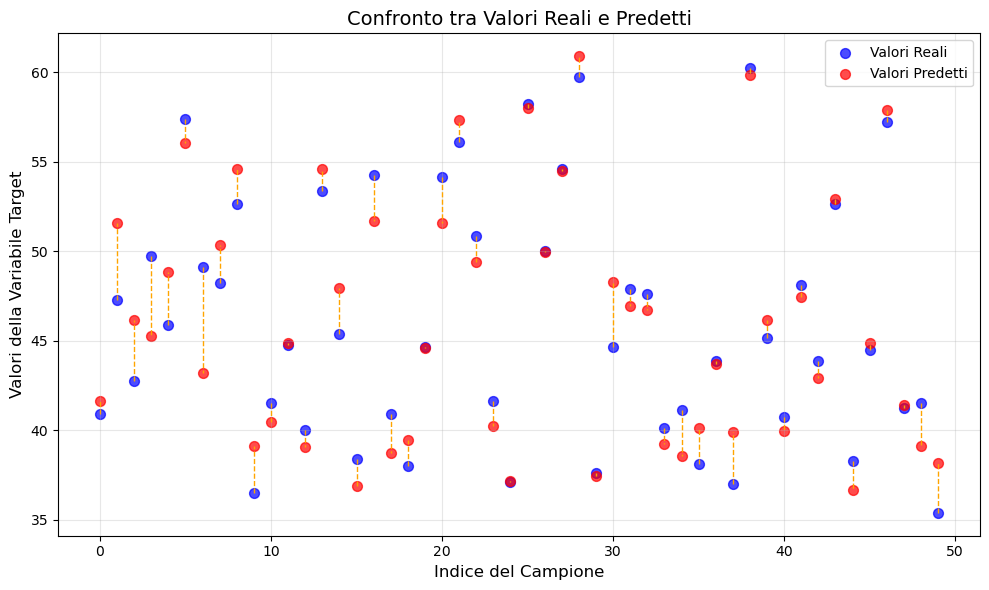

In [182]:
plt.figure(figsize=(10, 6))

plt.scatter(range(len(y_test[:50])), y_test[:50], color='blue', label='Valori Reali', s=50, alpha=0.7)

plt.scatter(range(len(y_pred[:50])), y_pred[:50], color='red', label='Valori Predetti', s=50, alpha=0.7)

for i, (y_real, y_predicted) in enumerate(zip(y_test[:50], y_pred[:50])):
    plt.plot([i, i], [y_real, y_predicted], color='orange', linestyle='--', linewidth=1)
    
plt.xlabel("Indice del Campione", fontsize=12)
plt.ylabel("Valori della Variabile Target", fontsize=12)
plt.title("Confronto tra Valori Reali e Predetti", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


#### 3.2 Decision Tree Regression

The second model is a Decision Tree adapted for regression. We imported, initialised, and fitted it in the same way, then evaluated it using the same metrics.

In [185]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train);


According to the chosen metrics, this model performs significantly better than the previous one, with substantial improvements across all metrics.
We saved the values in the dictionary for the overall comparison later.

In this case the model shows slight overfitting, as it produces near-zero error metrics when tested on the training set.

In [187]:
y_pred_temp = dt_model.predict(X_test)
y_pred= scaler_y.inverse_transform(y_pred_temp.reshape(-1,1)).ravel()

mae = round(mean_absolute_error(y_test, y_pred), 3)
mape = round(mean_absolute_percentage_error(y_test, y_pred), 3)
rmse = round(root_mean_squared_error(y_test, y_pred), 3)
smape= round(symmetric_mean_absolute_percentage_error(y_test, y_pred), 3)

metriche['decisionTreeRegression']= {
    'mae': mae,
    'mape': mape,
    'rmse': rmse,
    'smape': smape
}

print("Error Metrics sul test set")
print("Mean Absolute Error:", mae)
print("Mean Absolute percentage error:", mape)
print("Root Mean Squared Error:", rmse)
print("Symmetric Mean Absolute Percentage Error:", smape)


#test sul training set per verificare la presenza di overfitting
y_pred_temp_prova = dt_model.predict(X_train)
y_pred_prova= scaler_y.inverse_transform(y_pred_temp_prova.reshape(-1,1)).ravel()

mae = round(mean_absolute_error(y_train_init, y_pred_prova), 3)
mape = round(mean_absolute_percentage_error(y_train_init, y_pred_prova), 3)
rmse = round(root_mean_squared_error(y_train_init, y_pred_prova), 3)
smape= round(symmetric_mean_absolute_percentage_error(y_train_init, y_pred_prova), 3)

print("\nError Metrics sul training set")
print("Mean Absolute Error:", mae)
print("Mean Absolute percentage error:", mape)
print("Root Mean Squared Error:", rmse)
print("Symmetric Mean Absolute Percentage Error:", smape)

Error Metrics sul test set
Mean Absolute Error: 0.67
Mean Absolute percentage error: 0.014
Root Mean Squared Error: 1.0
Symmetric Mean Absolute Percentage Error: 0.007

Error Metrics sul training set
Mean Absolute Error: 0.0
Mean Absolute percentage error: 0.0
Root Mean Squared Error: 0.0
Symmetric Mean Absolute Percentage Error: 0.0


We also printed the decision tree to get a sense of its complexity.

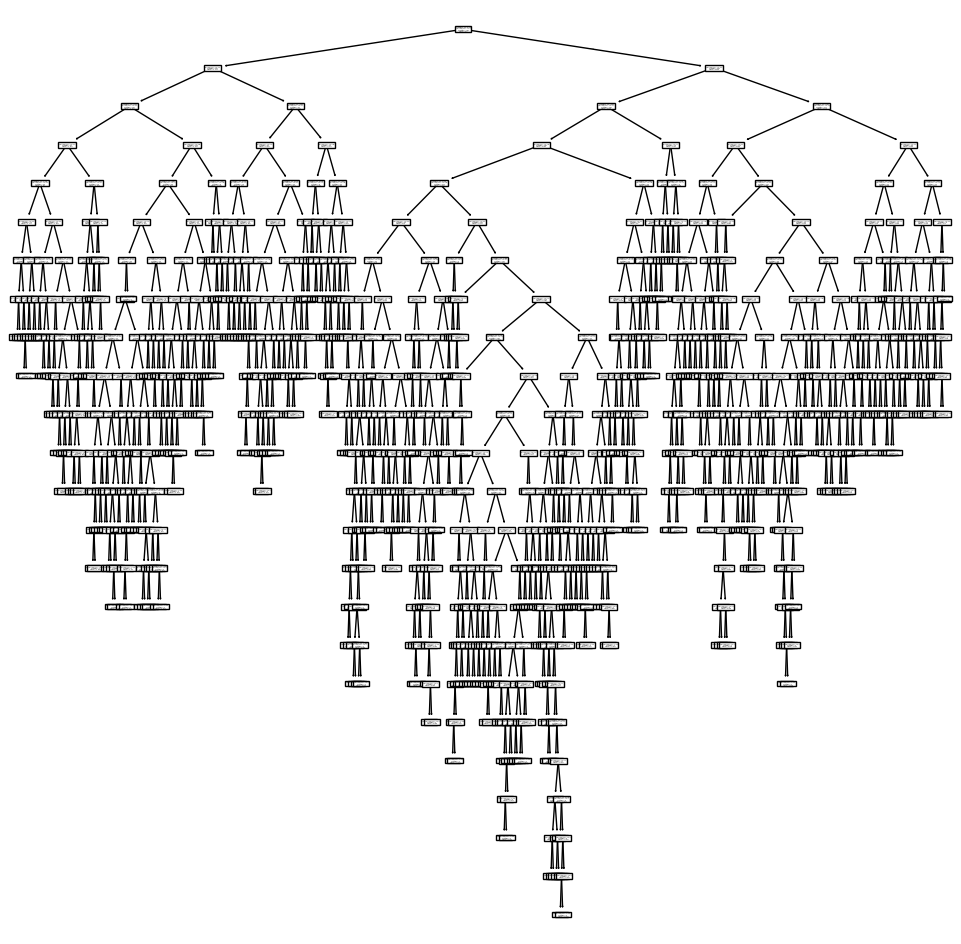

In [189]:
from sklearn.tree import plot_tree

ax = plt.subplots(figsize =(12,12))[1]
plot_tree(dt_model,
          feature_names=X_train_init.columns,
          ax=ax);

We again plotted the comparison between real and predicted values, confirming better performance and results compared to the previous model.

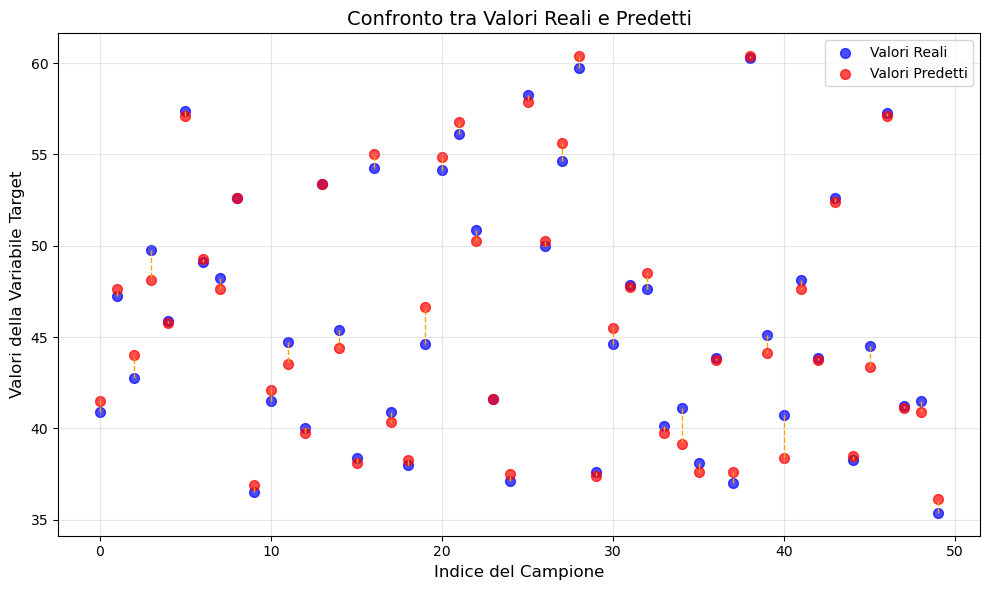

In [191]:
plt.figure(figsize=(10, 6))

plt.scatter(range(len(y_test[:50])), y_test[:50], color='blue', label='Valori Reali', s=50, alpha=0.7)

plt.scatter(range(len(y_pred[:50])), y_pred[:50], color='red', label='Valori Predetti', s=50, alpha=0.7)

for i, (y_real, y_predicted) in enumerate(zip(y_test[:50], y_pred[:50])):
    plt.plot([i, i], [y_real, y_predicted], color='orange', linestyle='--', linewidth=1)
    
plt.xlabel("Indice del Campione", fontsize=12)
plt.ylabel("Valori della Variabile Target", fontsize=12)
plt.title("Confronto tra Valori Reali e Predetti", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

We performed a feature importance analysis for this model, which revealed that `company1` is by far the most relevant predictor of the target variable, followed by `company9`.

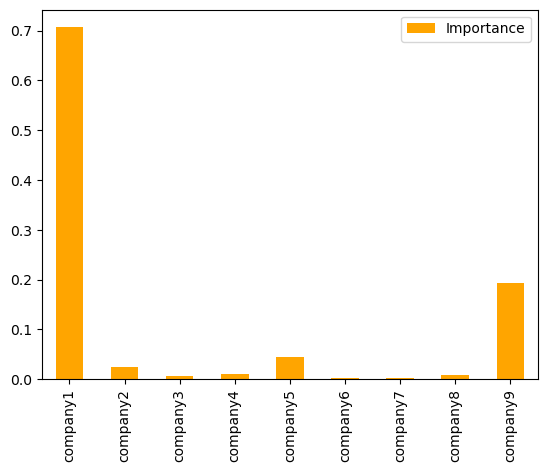

In [193]:
importance = pd.DataFrame({'Importance':dt_model.feature_importances_}, index=X_train_init.columns)
importance.plot.bar(color="orange");

#### 3.3 Random Forest Regression

The third model is an ensemble method: Random Forest. We imported, initialised, and fitted it as before.

In [196]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train);


The Random Forest model, according to the chosen metrics, performs slightly better than the previous two.
We saved the values in the dictionary as before.

In this case there is no significant overfitting or underfitting — errors are similar and reasonably low on both training and test sets, though the model does not achieve perfect performance even on the training set.

In [198]:
y_pred_temp = rf_model.predict(X_test)
y_pred_rf= scaler_y.inverse_transform(y_pred_temp.reshape(-1,1)).ravel()

mae = round(mean_absolute_error(y_test, y_pred_rf), 3)
mape = round(mean_absolute_percentage_error(y_test, y_pred_rf), 3)
rmse = round(root_mean_squared_error(y_test, y_pred_rf), 3)
smape= round(symmetric_mean_absolute_percentage_error(y_test, y_pred_rf), 3)

metriche['randomForestRegression']= {
    'mae': mae,
    'mape': mape,
    'rmse': rmse,
    'smape': smape
}

print("Error Metrics sul test set")
print("Mean Absolute Error:", mae)
print("Mean Absolute percentage error:", mape)
print("Root Mean Squared Error:", rmse)
print("Symmetric Mean Absolute Percentage Error:", smape)


#test sul training set per verificare la presenza di overfitting
y_pred_temp_prova = rf_model.predict(X_train)
y_pred_prova= scaler_y.inverse_transform(y_pred_temp_prova.reshape(-1,1)).ravel()

mae = round(mean_absolute_error(y_train_init, y_pred_prova), 3)
mape = round(mean_absolute_percentage_error(y_train_init, y_pred_prova), 3)
rmse = round(root_mean_squared_error(y_train_init, y_pred_prova), 3)
smape= round(symmetric_mean_absolute_percentage_error(y_train_init, y_pred_prova), 3)

print("\nError Metrics sul training set")
print("Mean Absolute Error:", mae)
print("Mean Absolute percentage error:", mape)
print("Root Mean Squared Error:", rmse)
print("Symmetric Mean Absolute Percentage Error:", smape)

Error Metrics sul test set
Mean Absolute Error: 0.568
Mean Absolute percentage error: 0.012
Root Mean Squared Error: 0.863
Symmetric Mean Absolute Percentage Error: 0.006

Error Metrics sul training set
Mean Absolute Error: 0.228
Mean Absolute percentage error: 0.005
Root Mean Squared Error: 0.346
Symmetric Mean Absolute Percentage Error: 0.002


The comparison plot confirms the stronger performance.

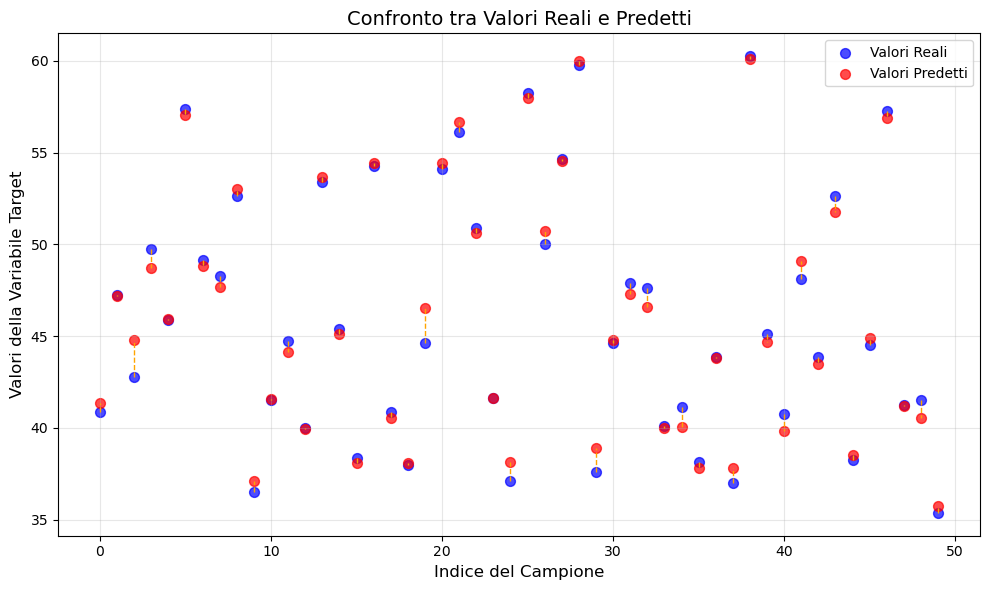

In [200]:
plt.figure(figsize=(10, 6))

plt.scatter(range(len(y_test[:50])), y_test[:50], color='blue', label='Valori Reali', s=50, alpha=0.7)

plt.scatter(range(len(y_pred_rf[:50])), y_pred_rf[:50], color='red', label='Valori Predetti', s=50, alpha=0.7)

for i, (y_real, y_predicted) in enumerate(zip(y_test[:50], y_pred_rf[:50])):
    plt.plot([i, i], [y_real, y_predicted], color='orange', linestyle='--', linewidth=1)
    
plt.xlabel("Indice del Campione", fontsize=12)
plt.ylabel("Valori della Variabile Target", fontsize=12)
plt.title("Confronto tra Valori Reali e Predetti", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

According to the Random Forest as well, the most important feature is `company1`, followed by `company9`.

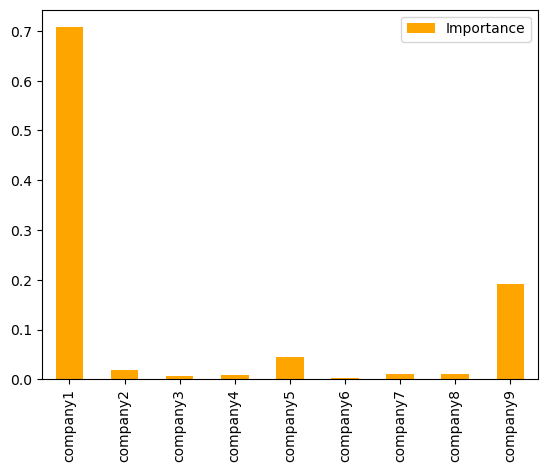

In [202]:
importance = pd.DataFrame({'Importance':rf_model.feature_importances_}, index=X_train_init.columns)
importance.plot.bar(color="orange");

#### 3.4 Gradient Boosting Regressor

The final model is Gradient Boosting, which we imported, initialised, and fitted as usual.

In [205]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)

gb_model.fit(X_train, y_train);


This time, according to the chosen metrics, the model performs slightly worse than Random Forest and in some metrics also worse than Decision Tree. However, Gradient Boosting still clearly outperforms Linear Regression.
We saved the values as usual for the final comparison.

There may be a very slight underfitting in this case.

In [207]:
y_pred_temp = gb_model.predict(X_test)
y_pred= scaler_y.inverse_transform(y_pred_temp.reshape(-1,1)).ravel()

mae = round(mean_absolute_error(y_test, y_pred), 3)
mape = round(mean_absolute_percentage_error(y_test, y_pred), 3)
rmse = round(root_mean_squared_error(y_test, y_pred), 3)
smape= round(symmetric_mean_absolute_percentage_error(y_test, y_pred), 3)

metriche['gradientBoostingRegression']= {
    'mae': mae,
    'mape': mape,
    'rmse': rmse,
    'smape': smape
}

print("Error Metrics sul test set")
print("Mean Absolute Error:", mae)
print("Mean Absolute percentage error:", mape)
print("Root Mean Squared Error:", rmse)
print("Symmetric Mean Absolute Percentage Error:", smape)


#test sul training set per verificare la presenza di overfitting
y_pred_temp_prova = gb_model.predict(X_train)
y_pred_prova= scaler_y.inverse_transform(y_pred_temp_prova.reshape(-1,1)).ravel()

mae = round(mean_absolute_error(y_train_init, y_pred_prova), 3)
mape = round(mean_absolute_percentage_error(y_train_init, y_pred_prova), 3)
rmse = round(root_mean_squared_error(y_train_init, y_pred_prova), 3)
smape= round(symmetric_mean_absolute_percentage_error(y_train_init, y_pred_prova), 3)

print("\nError Metrics sul training set")
print("Mean Absolute Error:", mae)
print("Mean Absolute percentage error:", mape)
print("Root Mean Squared Error:", rmse)
print("Symmetric Mean Absolute Percentage Error:", smape)

Error Metrics sul test set
Mean Absolute Error: 0.753
Mean Absolute percentage error: 0.016
Root Mean Squared Error: 1.012
Symmetric Mean Absolute Percentage Error: 0.008

Error Metrics sul training set
Mean Absolute Error: 0.511
Mean Absolute percentage error: 0.011
Root Mean Squared Error: 0.652
Symmetric Mean Absolute Percentage Error: 0.005


Finally, we also included the comparison plot between real and predicted values.

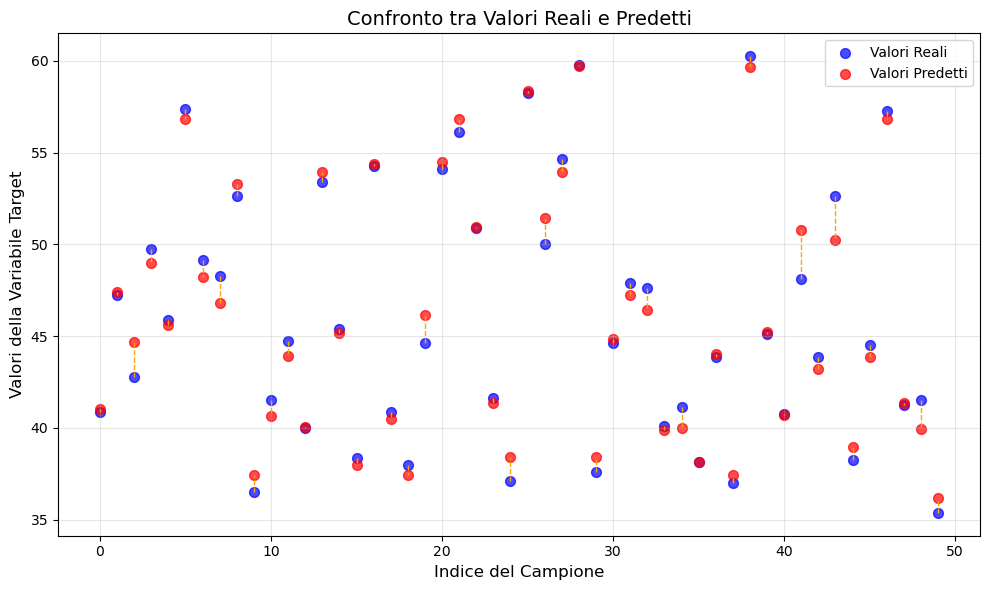

In [209]:
plt.figure(figsize=(10, 6))

plt.scatter(range(len(y_test[:50])), y_test[:50], color='blue', label='Valori Reali', s=50, alpha=0.7)

plt.scatter(range(len(y_pred[:50])), y_pred[:50], color='red', label='Valori Predetti', s=50, alpha=0.7)

for i, (y_real, y_predicted) in enumerate(zip(y_test[:50], y_pred[:50])):
    plt.plot([i, i], [y_real, y_predicted], color='orange', linestyle='--', linewidth=1)
    
plt.xlabel("Indice del Campione", fontsize=12)
plt.ylabel("Valori della Variabile Target", fontsize=12)
plt.title("Confronto tra Valori Reali e Predetti", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The feature importance analysis confirms the same variables as the other two models, with `company1` at the top.

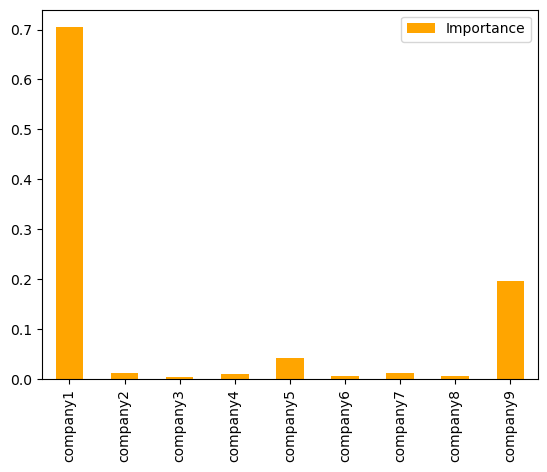

In [211]:
importance = pd.DataFrame({'Importance':gb_model.feature_importances_}, index=X_train_init.columns)
importance.plot.bar(color="orange");

Having noticed that `company1` consistently ranks as the most important predictor across all feature-importance-aware models, we printed the correlation matrix, which confirmed a fairly high correlation of 71% between `company1` and `company10`.

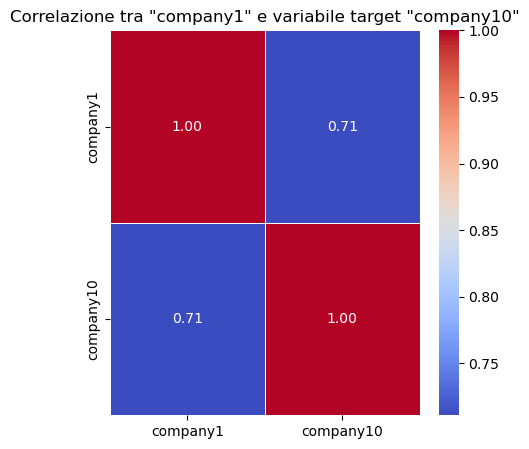

In [213]:
correlation= df[['company1', 'company10']].corr()

plt.figure(figsize=(5,5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlazione tra "company1" e variabile target "company10"')
plt.show()

We printed a chart combining all error metrics for every regressor.
As anticipated, Random Forest appears to be the best model for this problem, followed by Gradient Boosting and Decision Tree, which perform similarly.
Linear Regression, which initially seemed reasonable before comparing to other models, turns out to be the least performant regressor on this dataset.

The presence of outliers may also be negatively influencing model predictions.

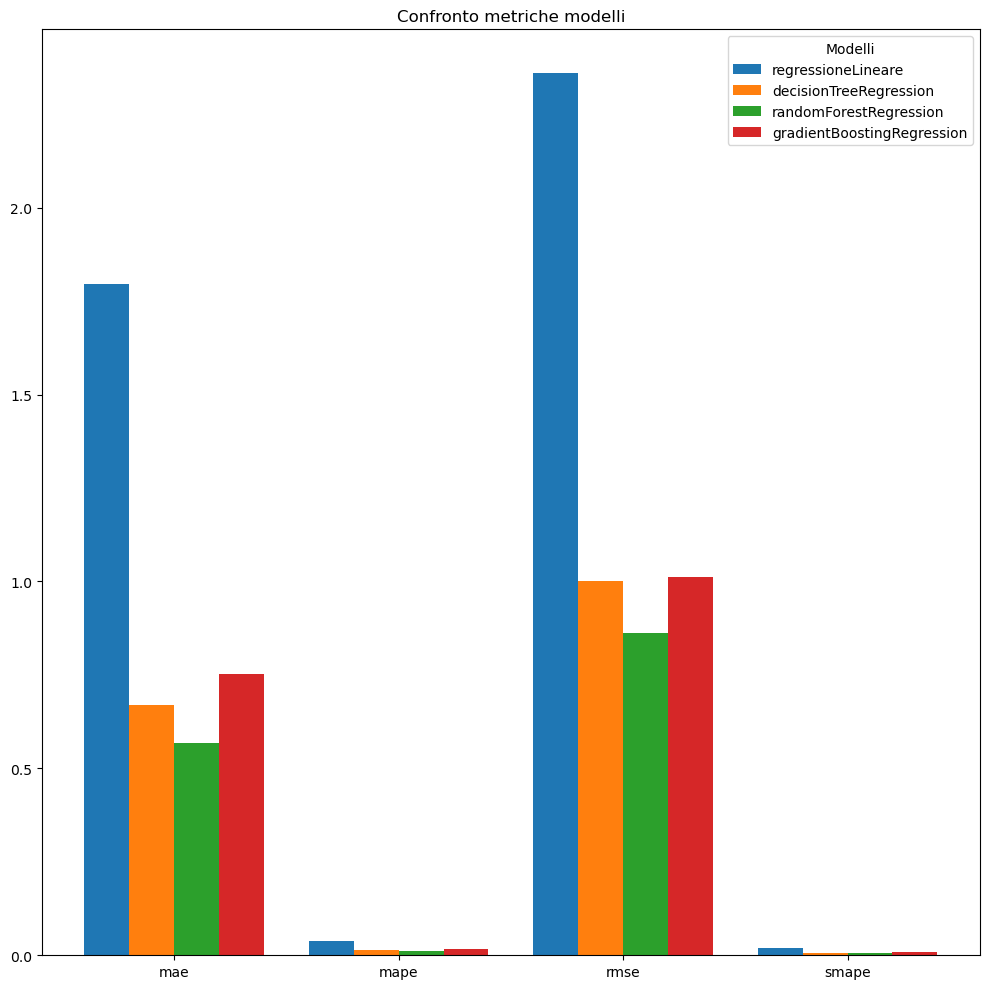

In [215]:
import numpy as np

campi = list(metriche["regressioneLineare"].keys())  
dizionari = list(metriche.keys())

valori = {campo: [metriche[dizionario][campo] for dizionario in dizionari] for campo in campi}

indici = np.arange(len(campi))  
larghezza = 0.2 

fig, ax = plt.subplots(figsize=(10, 10))

for i, dizionario in enumerate(dizionari):
    
    valori_dizionario = [valori[campo][i] for campo in campi]
    ax.bar(indici + i * larghezza, valori_dizionario, larghezza, label=dizionario)


ax.set_title('Confronto metriche modelli')
ax.set_xticks(indici + larghezza * (len(dizionari) - 1) / 2)  
ax.set_xticklabels(campi)  
ax.legend(title="Modelli")

plt.tight_layout()
plt.show()


We plotted a scatter plot of predicted vs. real values for the best model (Random Forest).
The close resemblance of the resulting shape to the bisector of the quadrant confirms the strong performance.

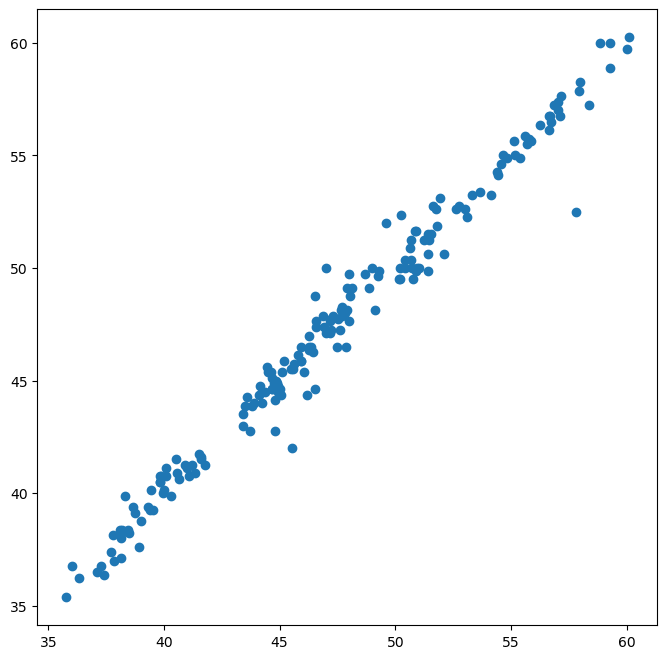

In [217]:
ax = plt.subplots(figsize =(8,8))[1]
ax.scatter(y_pred_rf , y_test);

#### 3.5 Experiments Repeated after PCA

We then applied dimensionality reduction to the features (excluding the target variable) using PCA as a feature extraction technique.

PCA was imported, set to 2 components, and applied to the data.

We also created a separate dictionary to store and compare post-PCA metrics.

In [220]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_reduced = pca.fit_transform(X_train)
X_test_reduced = pca.transform(X_test)



In [221]:
metrichePCA= {}

##### 3.5.1 Linear Regression

We applied the Linear Regression model again, this time on the reduced data.

In [224]:
model = LinearRegression()

model.fit(X_train_reduced, y_train);

According to our metrics, the model performs significantly worse after reducing the dimensionality to 2 components.
We saved the values in the new dictionary.

We again tested the model on the training set — since errors are fairly high on both sets, we conclude the presence of underfitting.

In [226]:
y_pred_temp = model.predict(X_test_reduced)
y_pred= scaler_y.inverse_transform(y_pred_temp.reshape(-1,1)).ravel()

mae = round(mean_absolute_error(y_test, y_pred), 3)
mape = round(mean_absolute_percentage_error(y_test, y_pred), 3)
rmse = round(root_mean_squared_error(y_test, y_pred), 3)
smape= round(symmetric_mean_absolute_percentage_error(y_test, y_pred), 3)

metrichePCA['regressioneLineare']= {
    'mae': mae,
    'mape': mape,
    'rmse': rmse,
    'smape': smape
}

print("Linear Regressor Coefficients")
print("Slope Coefficient:", round(model.coef_[0], 3))
print("Intercept:", round(model.intercept_, 3), "\n \n")

print("Error Metrics sul test set")
print("Mean Absolute Error:", mae)
print("Mean Absolute percentage error:", mape)
print("Root Mean Squared Error:", rmse)
print("Symmetric Mean Absolute Percentage Error:", smape)


#test sul training set per verificare la presenza di overfitting
y_pred_temp_prova = model.predict(X_train_reduced)
y_pred_prova= scaler_y.inverse_transform(y_pred_temp_prova.reshape(-1,1)).ravel()

mae = round(mean_absolute_error(y_train_init, y_pred_prova), 3)
mape = round(mean_absolute_percentage_error(y_train_init, y_pred_prova), 3)
rmse = round(root_mean_squared_error(y_train_init, y_pred_prova), 3)
smape= round(symmetric_mean_absolute_percentage_error(y_train_init, y_pred_prova), 3)

print("\nError Metrics sul training set")
print("Mean Absolute Error:", mae)
print("Mean Absolute percentage error:", mape)
print("Root Mean Squared Error:", rmse)
print("Symmetric Mean Absolute Percentage Error:", smape)

Linear Regressor Coefficients
Slope Coefficient: -0.244
Intercept: 0.0 
 

Error Metrics sul test set
Mean Absolute Error: 4.518
Mean Absolute percentage error: 0.095
Root Mean Squared Error: 5.29
Symmetric Mean Absolute Percentage Error: 0.048

Error Metrics sul training set
Mean Absolute Error: 5.045
Mean Absolute percentage error: 0.108
Root Mean Squared Error: 5.699
Symmetric Mean Absolute Percentage Error: 0.054


We again printed a comparison plot to visualise the distances between real and predicted values, which confirms the weaker performance.

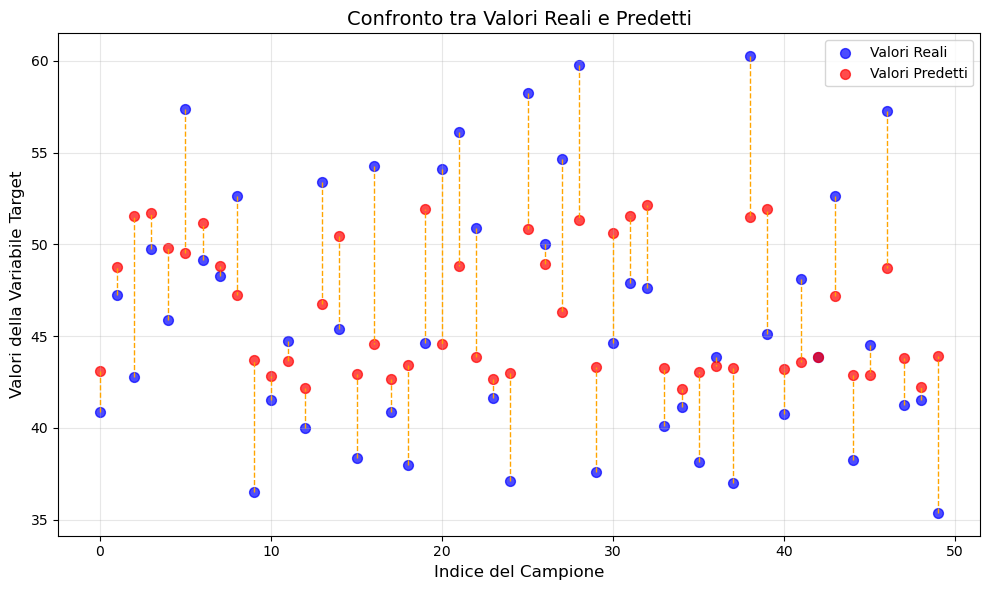

In [228]:
plt.figure(figsize=(10, 6))

plt.scatter(range(len(y_test[:50])), y_test[:50], color='blue', label='Valori Reali', s=50, alpha=0.7)

plt.scatter(range(len(y_pred[:50])), y_pred[:50], color='red', label='Valori Predetti', s=50, alpha=0.7)

for i, (y_real, y_predicted) in enumerate(zip(y_test[:50], y_pred[:50])):
    plt.plot([i, i], [y_real, y_predicted], color='orange', linestyle='--', linewidth=1)
    
plt.xlabel("Indice del Campione", fontsize=12)
plt.ylabel("Valori della Variabile Target", fontsize=12)
plt.title("Confronto tra Valori Reali e Predetti", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### 3.5.2 Decision Tree Regression

We repeat the regression with Decision Tree on the reduced data.

In [231]:
model = DecisionTreeRegressor(random_state=42)

model.fit(X_train_reduced, y_train);

The Decision Tree results also appear worse after dimensionality reduction, though still better than Linear Regression.
We saved the values for the final comparison.

In this case the model shows overfitting, as it produced zero errors on the training set.

In [233]:
y_pred_temp = model.predict(X_test_reduced)
y_pred= scaler_y.inverse_transform(y_pred_temp.reshape(-1,1)).ravel()

mae = round(mean_absolute_error(y_test, y_pred), 3)
mape = round(mean_absolute_percentage_error(y_test, y_pred), 3)
rmse = round(root_mean_squared_error(y_test, y_pred), 3)
smape= round(symmetric_mean_absolute_percentage_error(y_test, y_pred), 3)

metrichePCA['decisionTreeRegression']= {
    'mae': mae,
    'mape': mape,
    'rmse': rmse,
    'smape': smape
}

print("Error Metrics sul test set")
print("Mean Absolute Error:", mae)
print("Mean Absolute percentage error:", mape)
print("Root Mean Squared Error:", rmse)
print("Symmetric Mean Absolute Percentage Error:", smape)


#test sul training set per verificare la presenza di overfitting
y_pred_temp_prova = model.predict(X_train_reduced)
y_pred_prova= scaler_y.inverse_transform(y_pred_temp_prova.reshape(-1,1)).ravel()

mae = round(mean_absolute_error(y_train_init, y_pred_prova), 3)
mape = round(mean_absolute_percentage_error(y_train_init, y_pred_prova), 3)
rmse = round(root_mean_squared_error(y_train_init, y_pred_prova), 3)
smape= round(symmetric_mean_absolute_percentage_error(y_train_init, y_pred_prova), 3)

print("\nError Metrics sul training set")
print("Mean Absolute Error:", mae)
print("Mean Absolute percentage error:", mape)
print("Root Mean Squared Error:", rmse)
print("Symmetric Mean Absolute Percentage Error:", smape)

Error Metrics sul test set
Mean Absolute Error: 1.991
Mean Absolute percentage error: 0.042
Root Mean Squared Error: 3.601
Symmetric Mean Absolute Percentage Error: 0.021

Error Metrics sul training set
Mean Absolute Error: 0.0
Mean Absolute percentage error: 0.0
Root Mean Squared Error: 0.0
Symmetric Mean Absolute Percentage Error: 0.0


The comparison plot also confirms reduced errors compared to the previous model.

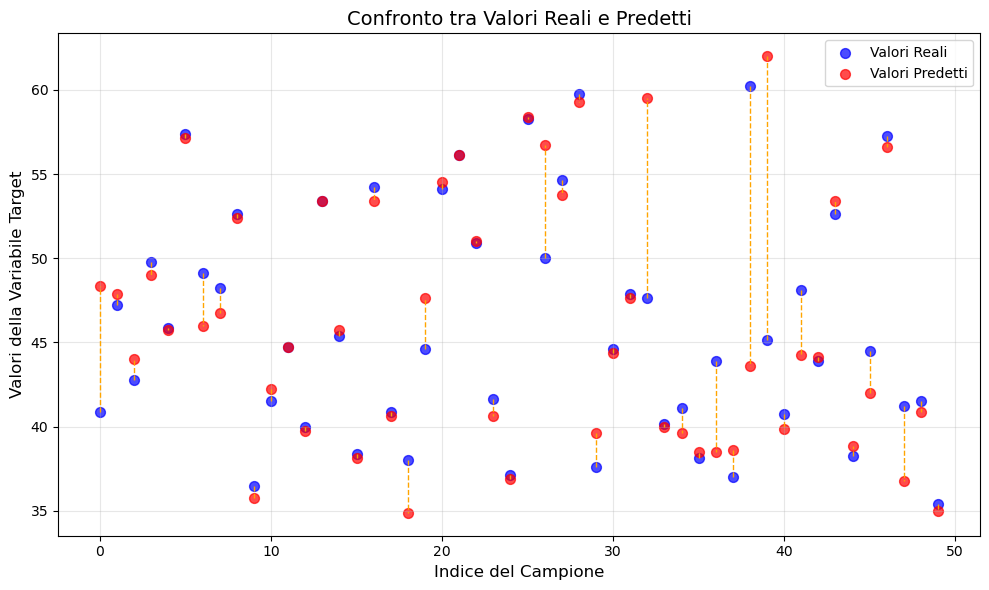

In [235]:
plt.figure(figsize=(10, 6))

plt.scatter(range(len(y_test[:50])), y_test[:50], color='blue', label='Valori Reali', s=50, alpha=0.7)

plt.scatter(range(len(y_pred[:50])), y_pred[:50], color='red', label='Valori Predetti', s=50, alpha=0.7)

for i, (y_real, y_predicted) in enumerate(zip(y_test[:50], y_pred[:50])):
    plt.plot([i, i], [y_real, y_predicted], color='orange', linestyle='--', linewidth=1)
    
plt.xlabel("Indice del Campione", fontsize=12)
plt.ylabel("Valori della Variabile Target", fontsize=12)
plt.title("Confronto tra Valori Reali e Predetti", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

We also plotted a feature importance chart for this model, and the first PCA component appears to be more relevant.

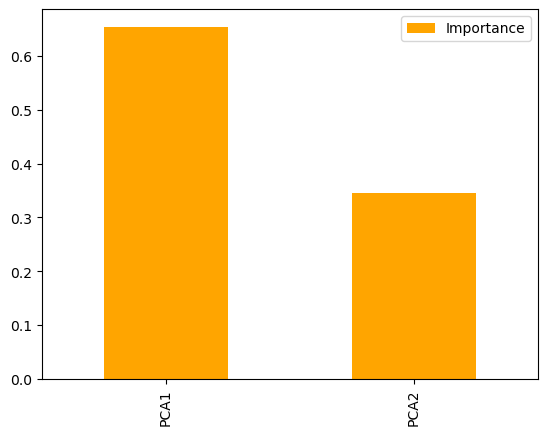

In [237]:
importance = pd.DataFrame({'Importance':model.feature_importances_}, index=["PCA1","PCA2"])
importance.plot.bar(color="orange");

##### 3.5.3 Random Forest Regression

We repeat the regression with Random Forest.

In [240]:
model = RandomForestRegressor(random_state=42)

model.fit(X_train_reduced, y_train);

From the metrics, the model performs similarly to the Decision Tree, with a slight advantage in Root Mean Squared Error.
However, predictions are again worse after data reduction.
We saved the values and moved on.

A slight underfitting is present, given the errors on the training set as well — though training set performance remains better than test set.

In [242]:
y_pred_temp = model.predict(X_test_reduced)
y_pred_rfpca= scaler_y.inverse_transform(y_pred_temp.reshape(-1,1)).ravel()

mae = round(mean_absolute_error(y_test, y_pred_rfpca), 3)
mape = round(mean_absolute_percentage_error(y_test, y_pred_rfpca), 3)
rmse = round(root_mean_squared_error(y_test, y_pred_rfpca), 3)
smape= round(symmetric_mean_absolute_percentage_error(y_test, y_pred_rfpca), 3)

metrichePCA['randomForestRegression']= {
    'mae': mae,
    'mape': mape,
    'rmse': rmse,
    'smape': smape
}

print("Error Metrics sul test set")
print("Mean Absolute Error:", mae)
print("Mean Absolute percentage error:", mape)
print("Root Mean Squared Error:", rmse)
print("Symmetric Mean Absolute Percentage Error:", smape)


#test sul training set per verificare la presenza di overfitting
y_pred_temp_prova = model.predict(X_train_reduced)
y_pred_prova= scaler_y.inverse_transform(y_pred_temp_prova.reshape(-1,1)).ravel()

mae = round(mean_absolute_error(y_train_init, y_pred_prova), 3)
mape = round(mean_absolute_percentage_error(y_train_init, y_pred_prova), 3)
rmse = round(root_mean_squared_error(y_train_init, y_pred_prova), 3)
smape= round(symmetric_mean_absolute_percentage_error(y_train_init, y_pred_prova), 3)

print("\nError Metrics sul training set")
print("Mean Absolute Error:", mae)
print("Mean Absolute percentage error:", mape)
print("Root Mean Squared Error:", rmse)
print("Symmetric Mean Absolute Percentage Error:", smape)

Error Metrics sul test set
Mean Absolute Error: 1.72
Mean Absolute percentage error: 0.036
Root Mean Squared Error: 2.829
Symmetric Mean Absolute Percentage Error: 0.018

Error Metrics sul training set
Mean Absolute Error: 0.623
Mean Absolute percentage error: 0.013
Root Mean Squared Error: 1.019
Symmetric Mean Absolute Percentage Error: 0.007


We again printed the comparison plot between real and predicted values.

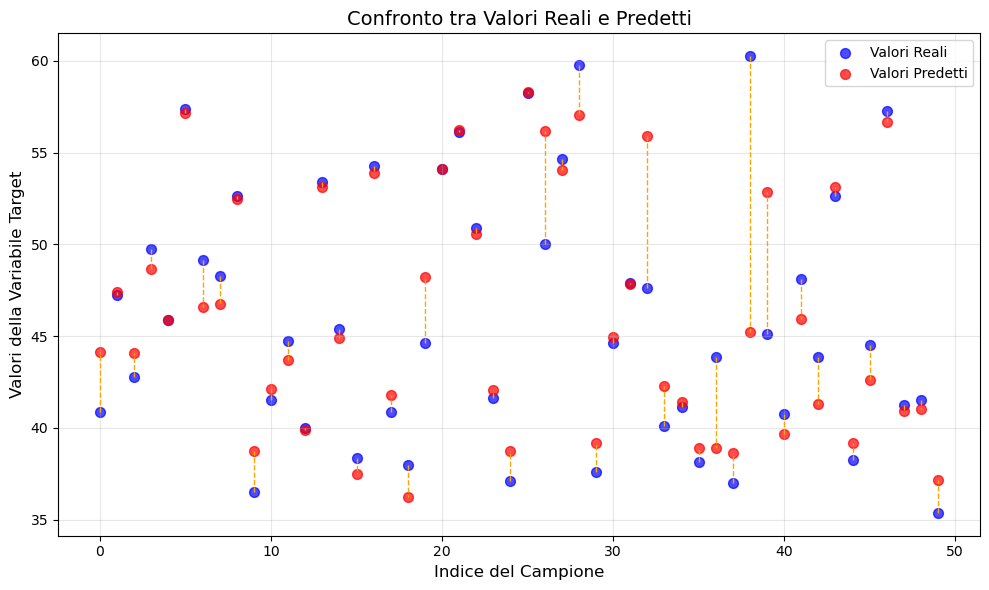

In [244]:
plt.figure(figsize=(10, 6))

plt.scatter(range(len(y_test[:50])), y_test[:50], color='blue', label='Valori Reali', s=50, alpha=0.7)

plt.scatter(range(len(y_pred_rfpca[:50])), y_pred_rfpca[:50], color='red', label='Valori Predetti', s=50, alpha=0.7)

for i, (y_real, y_predicted) in enumerate(zip(y_test[:50], y_pred_rfpca[:50])):
    plt.plot([i, i], [y_real, y_predicted], color='orange', linestyle='--', linewidth=1)
    
plt.xlabel("Indice del Campione", fontsize=12)
plt.ylabel("Valori della Variabile Target", fontsize=12)
plt.title("Confronto tra Valori Reali e Predetti", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The feature importance analysis again confirms the greater relevance of the first PCA component.

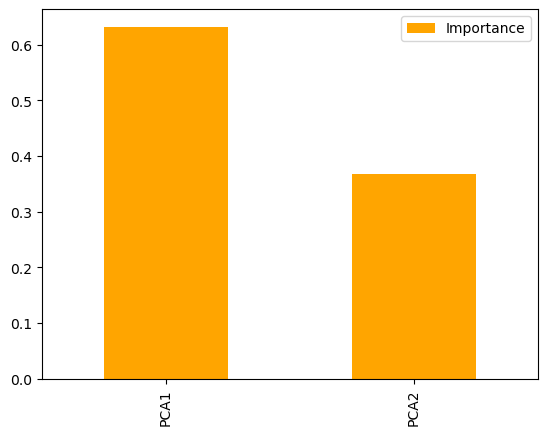

In [246]:
importance = pd.DataFrame({'Importance':model.feature_importances_}, index=["PCA1","PCA2"])
importance.plot.bar(color="orange");

##### 3.5.4 Gradient Boosting Regressor

Finally, we repeat the regression with Gradient Boosting.

In [249]:
model = GradientBoostingRegressor(random_state=42)

model.fit(X_train_reduced, y_train);

From the metrics, this model performs slightly worse than the previous two, except for RMSE.
Errors also increased here after data reduction.
We saved the values for the final comparison.

Underfitting is again present in this case.

In [251]:
y_pred_temp = model.predict(X_test_reduced)
y_pred= scaler_y.inverse_transform(y_pred_temp.reshape(-1,1)).ravel()

mae = round(mean_absolute_error(y_test, y_pred), 3)
mape = round(mean_absolute_percentage_error(y_test, y_pred), 3)
rmse = round(root_mean_squared_error(y_test, y_pred), 3)
smape= round(symmetric_mean_absolute_percentage_error(y_test, y_pred), 3)

metrichePCA['gradientBoostingRegression']= {
    'mae': mae,
    'mape': mape,
    'rmse': rmse,
    'smape': smape
}

print("Error Metrics sul test set")
print("Mean Absolute Error:", mae)
print("Mean Absolute percentage error:", mape)
print("Root Mean Squared Error:", rmse)
print("Symmetric Mean Absolute Percentage Error:", smape)


#test sul training set per verificare la presenza di overfitting
y_pred_temp_prova = model.predict(X_train_reduced)
y_pred_prova= scaler_y.inverse_transform(y_pred_temp_prova.reshape(-1,1)).ravel()

mae = round(mean_absolute_error(y_train_init, y_pred_prova), 3)
mape = round(mean_absolute_percentage_error(y_train_init, y_pred_prova), 3)
rmse = round(root_mean_squared_error(y_train_init, y_pred_prova), 3)
smape= round(symmetric_mean_absolute_percentage_error(y_train_init, y_pred_prova), 3)

print("\nError Metrics sul training set")
print("Mean Absolute Error:", mae)
print("Mean Absolute percentage error:", mape)
print("Root Mean Squared Error:", rmse)
print("Symmetric Mean Absolute Percentage Error:", smape)

Error Metrics sul test set
Mean Absolute Error: 2.009
Mean Absolute percentage error: 0.042
Root Mean Squared Error: 2.831
Symmetric Mean Absolute Percentage Error: 0.021

Error Metrics sul training set
Mean Absolute Error: 1.551
Mean Absolute percentage error: 0.033
Root Mean Squared Error: 2.104
Symmetric Mean Absolute Percentage Error: 0.017


We included the comparison plot here as well.

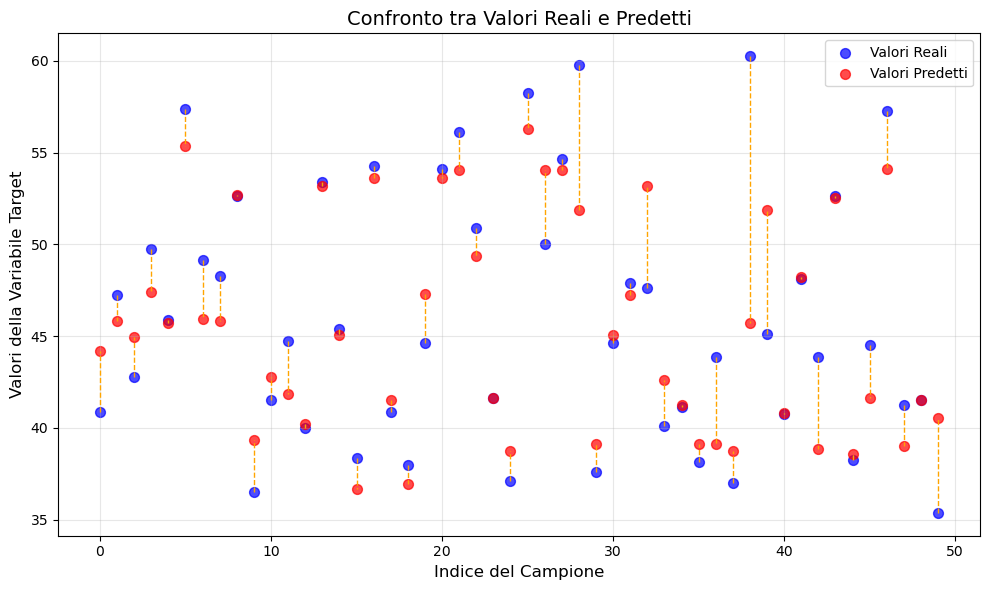

In [253]:
plt.figure(figsize=(10, 6))

plt.scatter(range(len(y_test[:50])), y_test[:50], color='blue', label='Valori Reali', s=50, alpha=0.7)

plt.scatter(range(len(y_pred[:50])), y_pred[:50], color='red', label='Valori Predetti', s=50, alpha=0.7)

for i, (y_real, y_predicted) in enumerate(zip(y_test[:50], y_pred[:50])):
    plt.plot([i, i], [y_real, y_predicted], color='orange', linestyle='--', linewidth=1)
    
plt.xlabel("Indice del Campione", fontsize=12)
plt.ylabel("Valori della Variabile Target", fontsize=12)
plt.title("Confronto tra Valori Reali e Predetti", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The feature importance chart definitively confirms the greater relevance of the first PCA component in predicting the target variable for this problem.

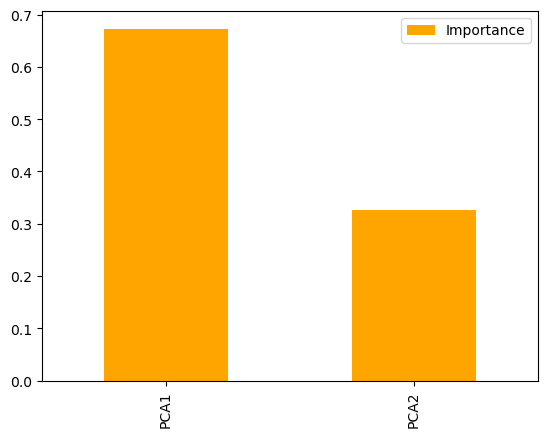

In [255]:
importance = pd.DataFrame({'Importance':model.feature_importances_}, index=["PCA1","PCA2"])
importance.plot.bar(color="orange");

We printed the error metrics chart for all models applied after PCA — the differences between models appear similar to those before PCA, with the exception of RMSE, where Gradient Boosting shows a very slight advantage.
However, all metrics worsened for all models compared to pre-PCA results.

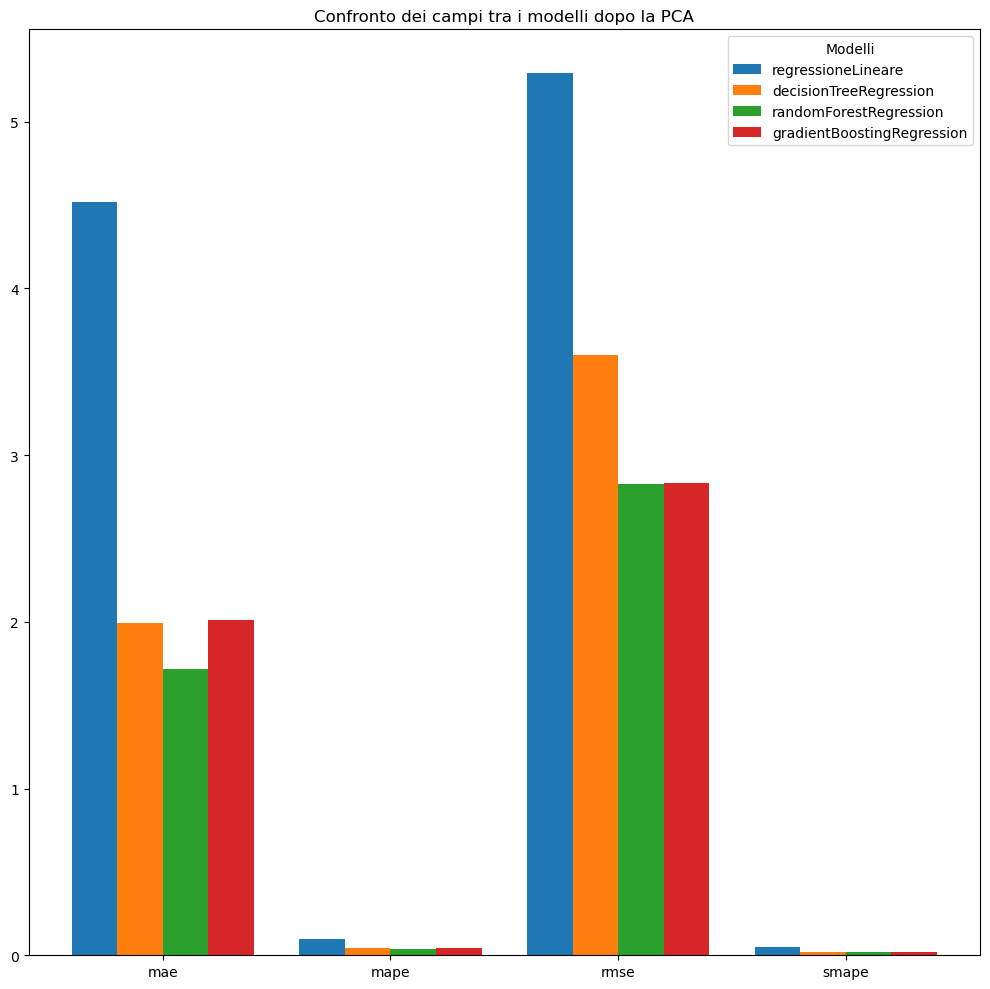

In [257]:
campi = list(metrichePCA["regressioneLineare"].keys())  
dizionari = list(metrichePCA.keys())

valori = {campo: [metrichePCA[dizionario][campo] for dizionario in dizionari] for campo in campi}

indici = np.arange(len(campi))  
larghezza = 0.2  

fig, ax = plt.subplots(figsize=(10, 10))

for i, dizionario in enumerate(dizionari):
    
    valori_dizionario = [valori[campo][i] for campo in campi]
    ax.bar(indici + i * larghezza, valori_dizionario, larghezza, label=dizionario)


ax.set_title('Confronto dei campi tra i modelli dopo la PCA')
ax.set_xticks(indici + larghezza * (len(dizionari) - 1) / 2)  
ax.set_xticklabels(campi)  
ax.legend(title="Modelli")

plt.tight_layout()
plt.show()


To further confirm that post-PCA metrics indicate weaker performance, we printed the scatter plot for the best post-PCA model (Random Forest) — the values are more scattered compared to before.

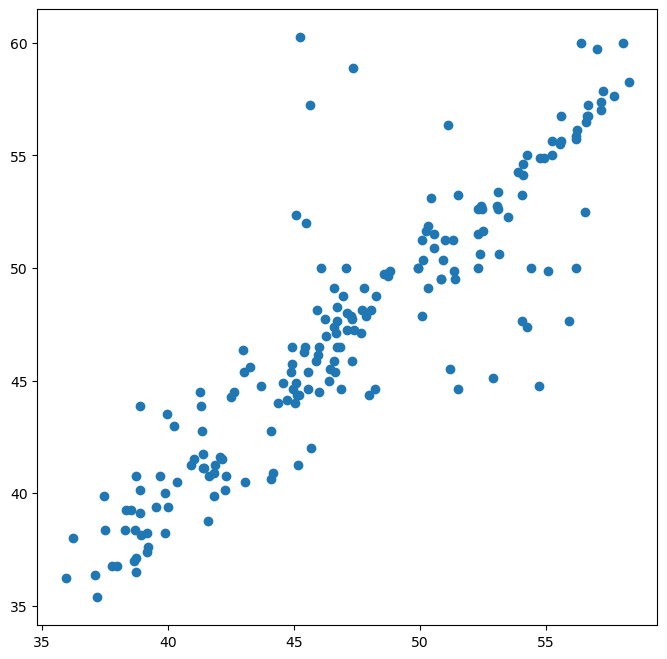

In [259]:
ax = plt.subplots(figsize =(8,8))[1]
ax.scatter(y_pred_rfpca , y_test);

Having confirmed that post-PCA models produce higher errors, we printed a direct comparison between the best pre-PCA and best post-PCA model, confirming that the best model after PCA performs significantly worse than the same model without dimensionality reduction.

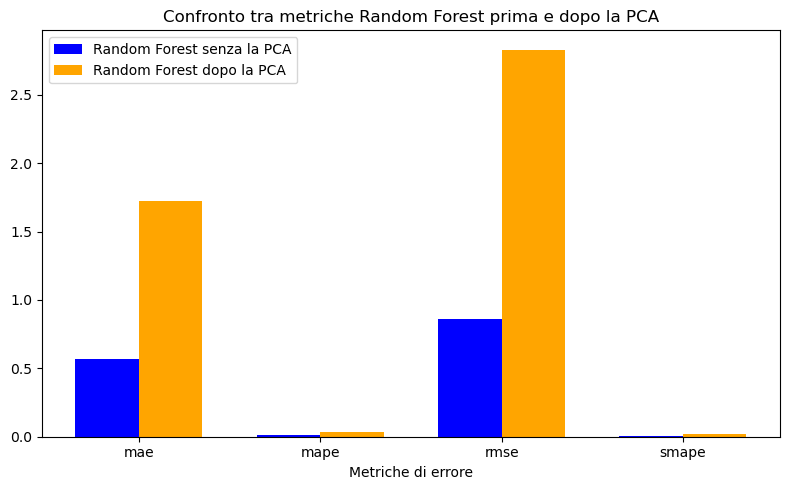

In [261]:
campi = list(metriche['randomForestRegression'].keys())
valori1 = list(metriche['randomForestRegression'].values())
valori2 = list(metrichePCA['randomForestRegression'].values())

x = np.arange(len(campi))

bar_width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - bar_width/2, valori1, width=bar_width, label="Random Forest senza la PCA", color='blue')
plt.bar(x + bar_width/2, valori2, width=bar_width, label="Random Forest dopo la PCA", color='orange')

plt.xlabel("Metriche di errore")
plt.title("Confronto tra metriche Random Forest prima e dopo la PCA")
plt.xticks(x, campi)  
plt.legend()

plt.tight_layout()
plt.show()


Given the sharp drop in performance after PCA, we immediately considered whether feature selection might have been more appropriate — the feature importance analysis across all applicable pre-PCA models suggested that only 2 or 3 variables are truly important for predicting the target.

We also considered that 2 might be a suboptimal number of components, so we printed the cumulative explained variance chart to determine the optimal number of components that minimises information loss while still reducing dimensionality.
The chart confirmed that 2 components is clearly not optimal given the information loss, and that 3 or 4 components would likely be a better choice.

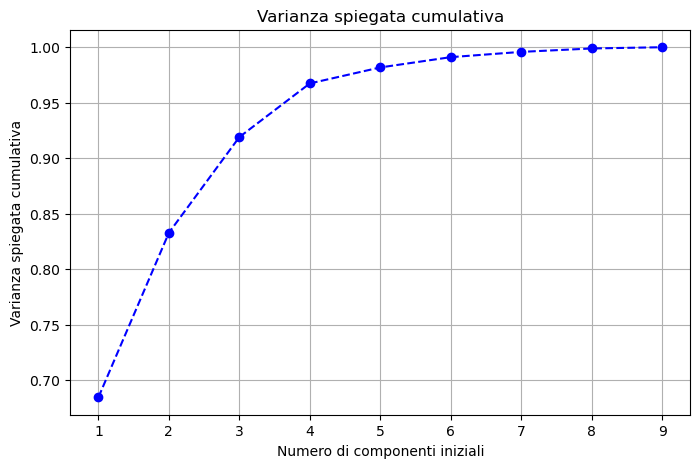

In [263]:
pca = PCA()
reduced_data = pca.fit_transform(X)


explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.title('Varianza spiegata cumulativa')
plt.xlabel('Numero di componenti iniziali')
plt.ylabel('Varianza spiegata cumulativa')
plt.grid()
plt.show()